<a href="https://colab.research.google.com/github/Parsahm86/pytorch_learning/blob/main/01_pytorch_Workflow/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch as t

In [ ]:
bias = 0.1
weight = 0.3

start = 0
end = 1
step = 0.01
X = t.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

print(f'\n------------\n{X}\n---------\n{Y}')


------------
tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900],
        [0.1000],
        [0.1100],
        [0.1200],
        [0.1300],
        [0.1400],
        [0.1500],
        [0.1600],
        [0.1700],
        [0.1800],
        [0.1900],
        [0.2000],
        [0.2100],
        [0.2200],
        [0.2300],
        [0.2400],
        [0.2500],
        [0.2600],
        [0.2700],
        [0.2800],
        [0.2900],
        [0.3000],
        [0.3100],
        [0.3200],
        [0.3300],
        [0.3400],
        [0.3500],
        [0.3600],
        [0.3700],
        [0.3800],
        [0.3900],
        [0.4000],
        [0.4100],
        [0.4200],
        [0.4300],
        [0.4400],
        [0.4500],
        [0.4600],
        [0.4700],
        [0.4800],
        [0.4900],
        [0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.540

In [ ]:
split = int(0.8 * len(X))
X_train, Y_train = X[:split], Y[:split]
X_test, Y_test = X[split:], Y[split:]
# print(f'\n-----X_train-------\n{X_train}\n----Y_trian-----\n{Y_train}')
# print(f'\n------X_test------\n{X_test}\n----Y_test-----\n{Y_test}')
print(f"\n ----------- X_train --------------- \n {X_train.shape}")
print(f"\n ------------- Y_train --------------- \n {Y_train.shape}")
print(f"\n ------------- X_test --------------- \n {X_test.shape}")
print(f"\n ------------- Y_test --------------- \n {Y_test.shape}")


 ----------- X_train --------------- 
 torch.Size([80, 1])

 ------------- Y_train --------------- 
 torch.Size([80, 1])

 ------------- X_test --------------- 
 torch.Size([20, 1])

 ------------- Y_test --------------- 
 torch.Size([20, 1])


In [ ]:
# predictions plot
import matplotlib.pyplot as plt
def predictions_plot(
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_test,
    test_labels=Y_test,
    predictions=None
  ):

  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, color='green', linewidths=10  , label='Training Data')
  plt.scatter(test_data, test_labels, color='b', linewidths=10, label='Testing Data')
  if predictions is not None:
    plt.scatter(test_data, predictions, color='r',linewidths=1, label='Predictions')

  plt.title('Predictions plot', color='black', fontsize=15, fontweight='bold')
  plt.xlabel('data', color='black', fontsize=12, fontweight='bold')
  plt.ylabel('Labels', color='black', fontsize=12, fontweight='bold')
  plt.tick_params(axis='both', color='red')
  plt.legend(prop={'size' : 13})
  plt.show()


In [ ]:
class LinearRegressionModel(t.nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = t.nn.Parameter(t.randn(1, requires_grad=True, dtype=t.float))
    self.bias = t.nn.Parameter(t.randn(1, requires_grad=True, dtype=t.float))
  def forward(self, x:t.tensor):
    return self.weights * x + self.bias

In [ ]:
# run model
t.manual_seed(42)
model = LinearRegressionModel()

In [ ]:
print(list(model.parameters()))
print('\n----------\n')
print(model.state_dict())

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]

----------

OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})


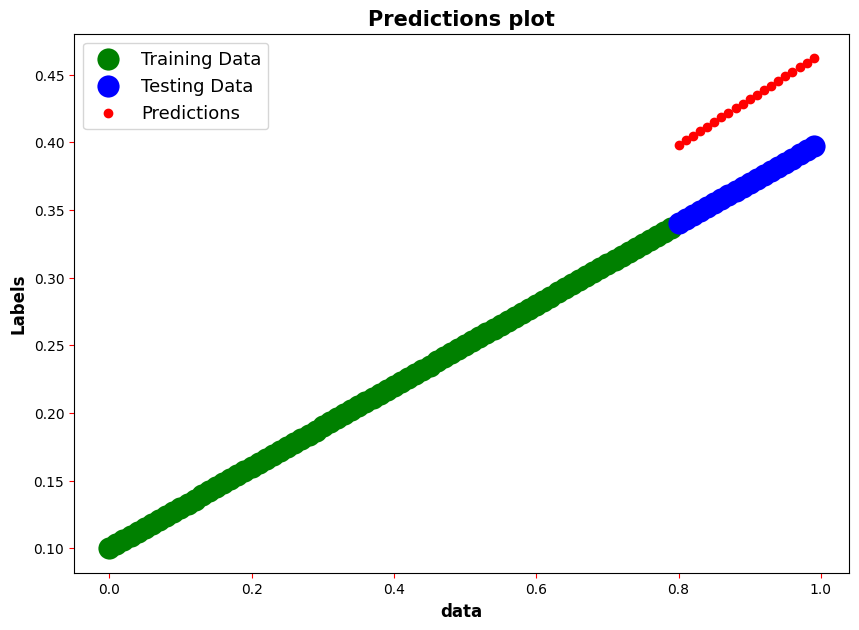

In [ ]:
with t.inference_mode():
  Y_preds_1 = model(X_test)


predictions_plot(predictions=Y_preds_1)

In [ ]:
# loss function
loss_fun = t.nn.L1Loss()

# Optimizer
optimizer = t.optim.SGD(params=model.parameters(),
                        lr=0.001)



In [ ]:
# training Phase
epochs_count = []
loss_train_values = []
loss_test_values = []

epochs = 200

for epoch in range(epochs):
  model.train()

  Y_preds_train = model(X_train)

  loss = loss_fun(Y_preds_train, Y_train)
  loss_train = loss.item()

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model.eval()
  with t.inference_mode():
    Y_preds_test = model(X_test)
    loss_test = loss_fun(Y_preds_test, Y_test)

  if epoch % 50 == 0 :
    print(f"----- epoch : {epoch:4d} | loss train : {loss_train:.4f} | loss test : {loss_test:.4f}")
    print('\n-------------')
    print(model.state_dict())
    epochs_count.append(epoch)
    loss_train_values.append(round(loss_train, 4))
    loss_test_values.append(round(loss_test.item(), 4))

----- epoch :    0 | loss train : 0.0433 | loss test : 0.0603

-------------
OrderedDict({'weights': tensor([0.3363]), 'bias': tensor([0.1278])})
----- epoch :   50 | loss train : 0.0038 | loss test : 0.0093

-------------
OrderedDict({'weights': tensor([0.3188]), 'bias': tensor([0.0925])})
----- epoch :  100 | loss train : 0.0021 | loss test : 0.0048

-------------
OrderedDict({'weights': tensor([0.3101]), 'bias': tensor([0.0957])})
----- epoch :  150 | loss train : 0.0004 | loss test : 0.0007

-------------
OrderedDict({'weights': tensor([0.3016]), 'bias': tensor([0.0993])})


final state dictionery after optimizations : OrderedDict({'weights': tensor([0.3009]), 'bias': tensor([0.1003])})
---------------------



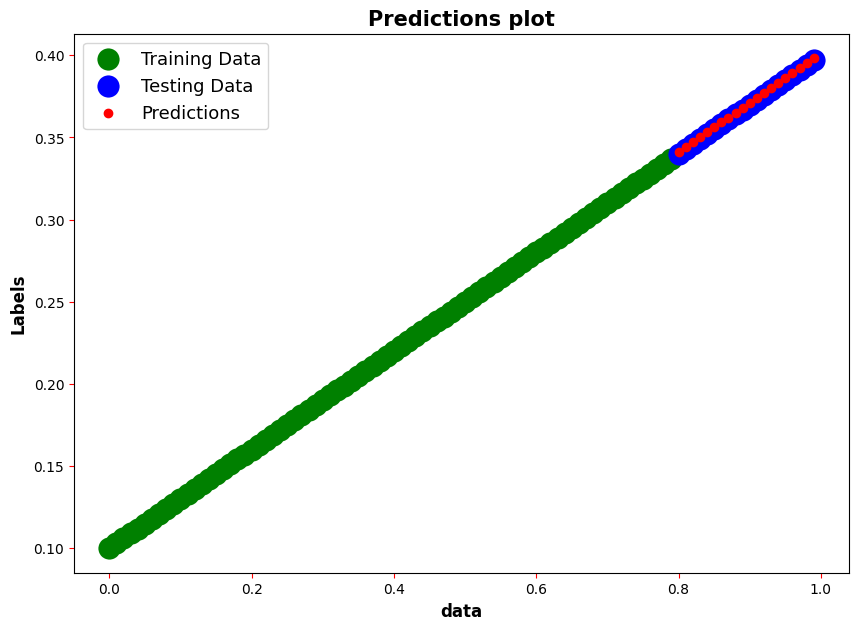

In [ ]:
print(f"final state dictionery after optimizations : {model.state_dict()}")
print('---------------------\n')

model.eval()
with t.inference_mode():
  Y_pred = model(X_test)

predictions_plot(predictions=Y_pred)

In [ ]:
print(epochs_count)
print('\n--------------\n')
print(loss_train_values)
print('\n--------------\n')
print(loss_test_values)

[0, 50, 100, 150]

--------------

[0.0433, 0.0038, 0.0021, 0.0004]

--------------

[0.0603, 0.0093, 0.0048, 0.0007]


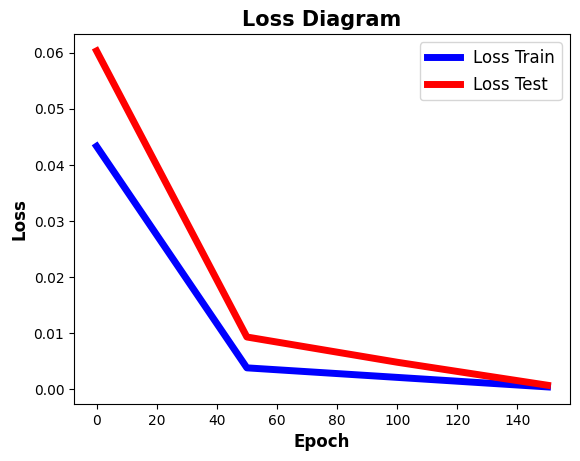

In [ ]:
plt.plot(epochs_count, loss_train_values, linewidth=5, color='b', label='Loss Train')
plt.plot(epochs_count, loss_test_values, linewidth=5, color='r', label='Loss Test')
plt.title('Loss Diagram', color='black', fontsize=15, fontweight='bold')
plt.xlabel('Epoch', color='black', fontsize=12, fontweight='bold')
plt.ylabel('Loss', color='black', fontsize=12, fontweight='bold')
plt.legend(prop={'size':12})
plt.show()